# Exercise 9 - Linear SVM comparision

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier

In [2]:
iris = datasets.load_iris()

# Petal length and petal width
X = iris["data"][:, (2, 3)]
y = iris["target"]
setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

print("X shape:", X.shape)
print("Classes:", np.unique(y))

X shape: (100, 2)
Classes: [0 1]


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Means:", X_scaled.mean(axis=0))
print("Std:", X_scaled.std(axis=0))

Means: [-1.18793864e-16  3.36397576e-16]
Std: [1. 1.]


In [4]:
C = 5
alpha = 1 / (C * len(X))

lin_svc = LinearSVC(loss="hinge", C=C, random_state=42, max_iter=10000)
svc = SVC(kernel="linear", C=C)
sgd = SGDClassifier(loss="hinge", learning_rate="constant", eta0=0.001, alpha=alpha, max_iter=1000, tol=1e-3, random_state=42)

lin_svc.fit(X_scaled, y)
svc.fit(X_scaled, y)
sgd.fit(X_scaled, y)

SGDClassifier(alpha=0.002, eta0=0.001, learning_rate='constant',
              random_state=42)

In [5]:
print("LinearSVC")
print("Weights:", lin_svc.coef_)
print("Bias:", lin_svc.intercept_)

print("\nSVC")
print("Weights:", svc.coef_)
print("Bias:", svc.intercept_)

print("\nSGDClassifier")
print("Weights:", sgd.coef_)
print("Bias:", sgd.intercept_)

LinearSVC
Weights: [[1.05364854 1.09903804]]
Bias: [0.28475098]

SVC
Weights: [[1.1203284  1.02625193]]
Bias: [0.31896852]

SGDClassifier
Weights: [[0.77714169 0.72981762]]
Bias: [0.117]


In [6]:
pred_lin_svc = lin_svc.predict(X_scaled)
pred_svc = svc.predict(X_scaled)
pred_sgd = sgd.predict(X_scaled)

print("LinearSVC accuracy:", np.mean(pred_lin_svc == y))
print("SVC accuracy:", np.mean(pred_svc == y))
print("SGD accuracy:", np.mean(pred_sgd == y))

LinearSVC accuracy: 1.0
SVC accuracy: 1.0
SGD accuracy: 1.0


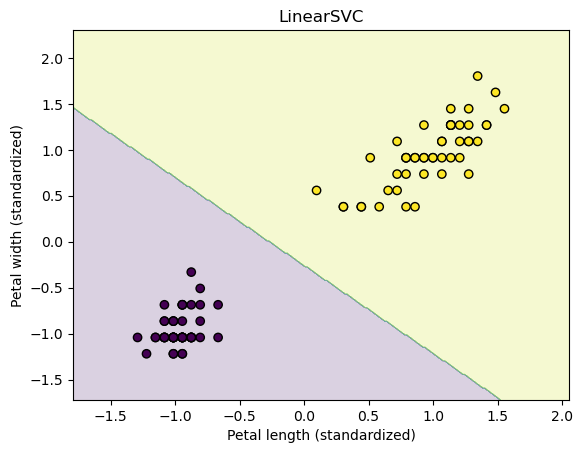

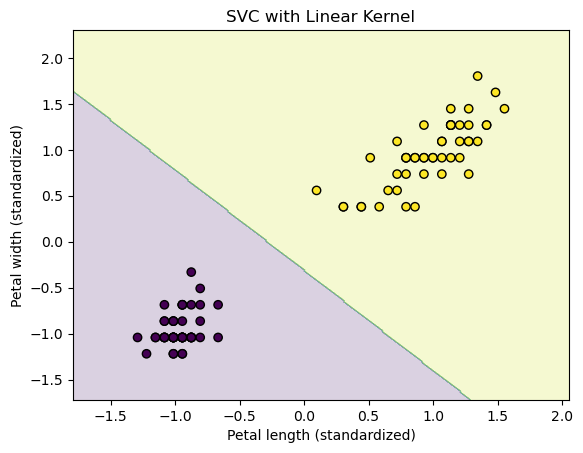

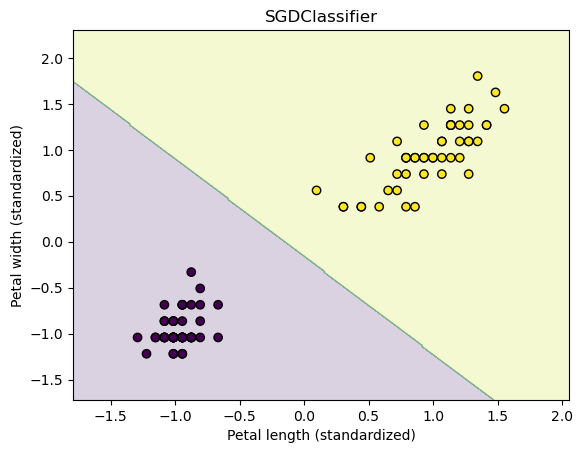

In [8]:
def plot_decision_boundary(model, X, y, title):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300), np.linspace(x1_min, x1_max, 300))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    Z = model.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, Z, alpha=0.2)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("Petal length (standardized)")
    plt.ylabel("Petal width (standardized)")
    plt.title(title)
    plt.show()

plot_decision_boundary(lin_svc, X_scaled, y, "LinearSVC")
plot_decision_boundary(svc, X_scaled, y, "SVC with Linear Kernel")
plot_decision_boundary(sgd, X_scaled, y, "SGDClassifier")

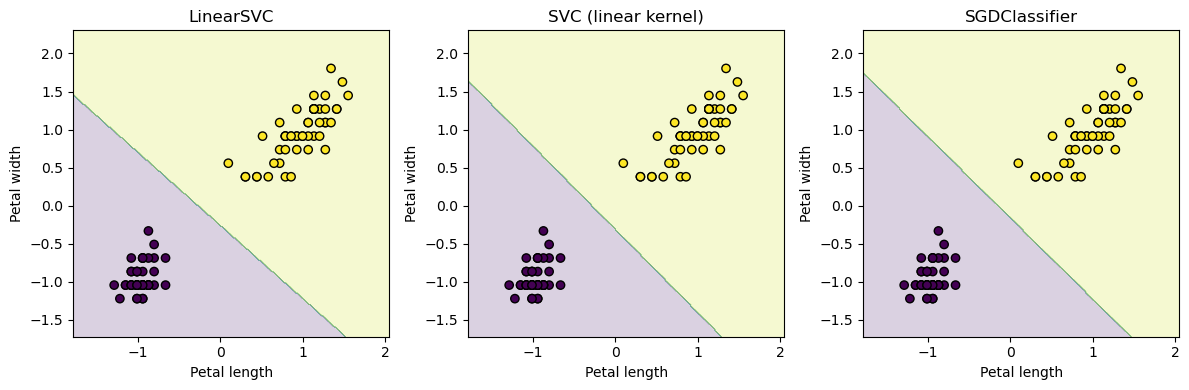

In [9]:
plt.figure(figsize=(12, 4))
models = [(lin_svc, "LinearSVC"), (svc, "SVC (linear kernel)"), (sgd, "SGDClassifier")]

for i, (model, title) in enumerate(models, 1):
    plt.subplot(1, 3, i)

    x0_min, x0_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    x1_min, x1_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 300), np.linspace(x1_min, x1_max, 300))

    grid = np.c_[xx0.ravel(), xx1.ravel()]
    Z = model.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, Z, alpha=0.2)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.xlabel("Petal length")
    plt.ylabel("Petal width")

plt.tight_layout()
plt.show()

In [10]:
print("LinearSVC vs SVC:", np.mean(pred_lin_svc == pred_svc))
print("LinearSVC vs SGD:", np.mean(pred_lin_svc == pred_sgd))
print("SVC vs SGD:", np.mean(pred_svc == pred_sgd))

LinearSVC vs SVC: 1.0
LinearSVC vs SGD: 1.0
SVC vs SGD: 1.0


In [11]:
print("Coefficient differences:")
print("LinearSVC vs SVC:", np.linalg.norm(lin_svc.coef_ - svc.coef_))
print("LinearSVC vs SGD:", np.linalg.norm(lin_svc.coef_ - sgd.coef_))
print("SVC vs SGD:", np.linalg.norm(svc.coef_ - sgd.coef_))

Coefficient differences:
LinearSVC vs SVC: 0.09871180841439436
LinearSVC vs SGD: 0.46128056162685327
SVC vs SGD: 0.45348695027613783


The data split being linearly separable, we get all three classifiers to perform perfectly though the margin/decision boundary is slightly different.